# **Radar por Percentiles - Qatar 2022**

- Cargo partidos de Qatar 2022.

- Descargo eventos de todos los partidos.

- Calculo minutos jugados por jugador.

- Asigno posición principal por jugador.

- Construyo métricas ofensivas.

- Llevo métricas de volumen a 90 minutos.

- Filtro jugadores por minutos mínimos y grupo posicional.

- Calculo percentiles dentro del universo elegido.

- Grafico el jugador objetivo con PyPizza.

In [263]:
from statsbombpy import sb
import pandas as pd
import numpy as np

from mplsoccer import PyPizza
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [264]:
import warnings
warnings.filterwarnings("ignore")

parámetros

In [307]:
nombre_competicion = "FIFA World Cup"
temporada = "2022"

jugador_objetivo = "Kylian Mbappé Lottin"

minutos_minimos = 180
grupo_posicion = "ofensivos"

incluir_penales = False

In [308]:
metricas_ofensivas = ["goles_p90", "xg_p90", "tiros_p90", "tiros_arco_p90",
    "asistencias_p90", "pases_clave_p90", "pases_progresivos_p90", "conducciones_progresivas_p90",
    "acciones_area_p90", "regates_ok_p90"]

In [309]:
df_competiciones = sb.competitions()

df_competicion_elegida = df_competiciones[
    (df_competiciones["competition_name"] == nombre_competicion) &
    (df_competiciones["season_name"] == temporada)].copy()

df_competicion_elegida

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
29,43,106,International,FIFA World Cup,male,False,True,2022,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845


In [310]:
competition_id = df_competicion_elegida["competition_id"].iloc[0]
season_id = df_competicion_elegida["season_id"].iloc[0]

competition_id, season_id

(43, 106)

In [311]:
df_partidos = sb.matches(competition_id=competition_id,season_id=season_id)

df_partidos.shape

(64, 55)

partidos

In [312]:
df_partidos[["match_id", "match_date", "home_team", "away_team", "home_score", "away_score", "competition_stage"]].head()

,match_id,match_date,home_team,away_team,home_score,away_score,competition_stage
0,3857256,2022-12-02,Serbia,Switzerland,2,3,Group Stage
1,3869151,2022-12-03,Argentina,Australia,2,1,Round of 16
2,3857257,2022-11-30,Australia,Denmark,1,0,Group Stage
3,3857258,2022-11-24,Brazil,Serbia,2,0,Group Stage
4,3857288,2022-11-26,Tunisia,Australia,0,1,Group Stage


eventos

In [313]:
lista_eventos = []

for match_id in df_partidos["match_id"]:

    df_eventos_partido = sb.events(match_id=match_id)
    df_eventos_partido["match_id"] = match_id
    
    lista_eventos.append(df_eventos_partido)


In [314]:
df_eventos = pd.concat(lista_eventos, ignore_index=True)

df_eventos.shape

(234652, 114)

In [315]:
df_eventos["type"].value_counts().head(20)

type
Pass               68515
Ball Receipt*      63715
Carry              53764
Pressure           16553
Ball Recovery       5821
Duel                4389
Clearance           2684
Block               2386
Dribble             1793
Goal Keeper         1790
Foul Committed      1775
Miscontrol          1755
Foul Won            1693
Shot                1494
Dispossessed        1431
Interception        1371
Dribbled Past       1036
Substitution         587
Injury Stoppage      403
Half Start           286
Name: count, dtype: int64

In [316]:
df_eventos[["match_id", "minute", "second", "team", "player", "position", "type"]].head()

,match_id,minute,second,team,player,position,type
0,3857256,0,0,Serbia,NaN,NaN,Starting XI
1,3857256,0,0,Switzerland,NaN,NaN,Starting XI
2,3857256,0,0,Switzerland,NaN,NaN,Half Start
3,3857256,0,0,Serbia,NaN,NaN,Half Start
4,3857256,45,0,Serbia,NaN,NaN,Half Start


eventos asociados a un jugador

In [317]:
df_eventos_jugador = df_eventos[df_eventos["player"].notna()].copy()

df_eventos_jugador.shape

(233544, 114)

In [318]:
df_eventos_jugador["position"].dropna().sort_values().unique()

array(['Center Attacking Midfield', 'Center Back',
       'Center Defensive Midfield', 'Center Forward', 'Goalkeeper',
       'Left Attacking Midfield', 'Left Back', 'Left Center Back',
       'Left Center Forward', 'Left Center Midfield',
       'Left Defensive Midfield', 'Left Midfield', 'Left Wing',
       'Left Wing Back', 'Right Attacking Midfield', 'Right Back',
       'Right Center Back', 'Right Center Forward',
       'Right Center Midfield', 'Right Defensive Midfield',
       'Right Midfield', 'Right Wing', 'Right Wing Back', 'Substitute'],
      dtype=object)

separo posiciones

In [319]:
#   posiciones_por_grupo = {
#       "ofensivos": ["Center Forward","Left Wing","Right Wing","Secondary Striker","Attacking Midfield"],
#       "mediocampistas": ["Center Midfield","Defensive Midfield","Left Midfield","Right Midfield","Left Center Midfield","Right Center Midfield"],
#       "laterales": ["Left Back","Right Back","Left Wing Back","Right Wing Back"],
#       "centrales": ["Center Back","Left Center Back","Right Center Back"],
#       "arqueros": ["Goalkeeper"],
#       "todos": []}

In [320]:
posiciones_por_grupo = {
    "ofensivos": ["Center Forward","Left Center Forward","Right Center Forward","Left Wing","Right Wing","Secondary Striker","Attacking Midfield","Center Attacking Midfield","Left Attacking Midfield","Right Attacking Midfield"],
    "mediocampistas": ["Center Midfield","Defensive Midfield","Left Midfield","Right Midfield","Left Center Midfield","Right Center Midfield"],
    "laterales": ["Left Back","Right Back","Left Wing Back","Right Wing Back"],
    "centrales": ["Center Back","Left Center Back","Right Center Back"],
    "arqueros": ["Goalkeeper"],
    "todos": []}

si no elijo alguna posición, me llevo todas al cálculo

In [321]:
if grupo_posicion == "todos":
    df_base_grupo = df_eventos_jugador.copy()
else:
    posiciones_elegidas = posiciones_por_grupo[grupo_posicion]
    
    df_base_grupo = df_eventos_jugador[df_eventos_jugador["position"].isin(posiciones_elegidas)].copy()

df_base_grupo.shape

(54735, 114)

In [322]:
df_base_grupo["position"].value_counts()

position
Right Wing                   12207
Left Wing                    12166
Center Forward               11263
Center Attacking Midfield     7520
Left Center Forward           4785
Right Center Forward          4766
Left Attacking Midfield       1028
Right Attacking Midfield      1000
Name: count, dtype: int64

calculo minutos totales del partido sin contar la tanda de penales

In [323]:
df_eventos["second"] = df_eventos["second"].fillna(0)

df_eventos["minuto_juego"] = (df_eventos["minute"] + df_eventos["second"] / 60)

df_fin_partido = (df_eventos[df_eventos["period"] <= 4].groupby("match_id", as_index=False).agg(minuto_final=("minuto_juego", "max")))

df_fin_partido.head()

,match_id,minuto_final
0,3857254,97.600000
1,3857255,97.016667
2,3857256,100.300000
3,3857257,96.050000
4,3857258,97.133333


alineaciones y posiciones

In [324]:
lista_lineups = []

for match_id in df_partidos["match_id"]:
    
    lineups_partido = sb.lineups(match_id=match_id)
    
    for equipo, df_equipo in lineups_partido.items():
        
        df_equipo = df_equipo.copy()
        df_equipo["team"] = equipo
        df_equipo["match_id"] = match_id
        
        lista_lineups.append(df_equipo)

In [325]:
df_lineups = pd.concat(lista_lineups, ignore_index=True)

df_lineups.shape

(3244, 9)

In [326]:
df_posiciones = df_lineups[["match_id", "team", "player_id", "player_name", "positions"]].explode("positions").copy()

df_posiciones = df_posiciones[df_posiciones["positions"].notna()].copy()

df_posiciones_detalle = pd.concat([
        df_posiciones.drop(columns="positions").reset_index(drop=True),
        pd.json_normalize(df_posiciones["positions"]).reset_index(drop=True)],axis=1)

df_posiciones_detalle.head()

,match_id,team,player_id,player_name,position_id,position,from,to,from_period,to_period,start_reason,end_reason
0,3857256,Switzerland,3500,Granit Xhaka,11,Left Defensive Midfield,00:00,None,1,NaN,Starting XI,Final Whistle
1,3857256,Switzerland,3533,Xherdan Shaqiri,17,Right Wing,00:00,68:17,1,2.0,Starting XI,Substitution - Off (Tactical)
2,3857256,Switzerland,3913,Edimilson Fernandes,19,Center Attacking Midfield,67:51,68:21,2,2.0,Substitution - On (Tactical),Tactical Shift
3,3857256,Switzerland,3913,Edimilson Fernandes,17,Right Wing,68:21,None,2,NaN,Tactical Shift,Final Whistle
4,3857256,Switzerland,5537,Fabian Lukas Schär,3,Right Center Back,00:00,None,1,NaN,Starting XI,Final Whistle


In [327]:
def convertir_tiempo_a_minutos(valor):
    
    if pd.isna(valor):
        return np.nan
    
    partes = str(valor).split(":")
    
    if len(partes) == 2:
        minutos = float(partes[0])
        segundos = float(partes[1])
        return minutos + segundos / 60
    
    if len(partes) == 3:
        horas = float(partes[0])
        minutos = float(partes[1])
        segundos = float(partes[2])
        return horas * 60 + minutos + segundos / 60
    
    return np.nan

In [328]:
df_posiciones_detalle = df_posiciones_detalle.merge(
    df_fin_partido,
    on="match_id",
    how="left"
)

df_posiciones_detalle["minuto_desde"] = (
    df_posiciones_detalle["from"]
    .apply(convertir_tiempo_a_minutos)
    .fillna(0)
)

df_posiciones_detalle["minuto_hasta"] = (
    df_posiciones_detalle["to"]
    .apply(convertir_tiempo_a_minutos)
)

df_posiciones_detalle["minuto_hasta"] = (
    df_posiciones_detalle["minuto_hasta"]
    .fillna(df_posiciones_detalle["minuto_final"])
)

df_posiciones_detalle["minutos_jugados"] = (
    df_posiciones_detalle["minuto_hasta"] -
    df_posiciones_detalle["minuto_desde"]
).clip(lower=0)

df_posiciones_detalle[
    ["player_name", "team", "position", "minuto_desde", "minuto_hasta", "minutos_jugados"]
].head(20)

,player_name,team,position,minuto_desde,minuto_hasta,minutos_jugados
0,Granit Xhaka,Switzerland,Left Defensive Midfield,0.000000,100.300000,100.300000
1,Xherdan Shaqiri,Switzerland,Right Wing,0.000000,68.283333,68.283333
2,Edimilson Fernandes,Switzerland,Center Attacking Midfield,67.850000,68.350000,0.500000
3,Edimilson Fernandes,Switzerland,Right Wing,68.350000,100.300000,31.950000
4,Fabian Lukas Schär,Switzerland,Right Center Back,0.000000,100.300000,100.300000
5,Denis Lemi Zakaria Lako Lado,Switzerland,Right Wing,68.283333,68.350000,0.066667
6,Denis Lemi Zakaria Lako Lado,Switzerland,Right Defensive Midfield,68.350000,100.300000,31.950000
7,Ricardo Iván Rodríguez Araya,Switzerland,Left Back,0.000000,100.300000,100.300000
8,Breel-Donald Embolo,Switzerland,Center Forward,0.000000,95.400000,95.400000
9,Manuel Obafemi Akanji,Switzerland,Left Center Back,0.000000,100.300000,100.300000


In [329]:
df_minutos = (
    df_posiciones_detalle
    .groupby(["player_name", "team"], as_index=False)
    .agg(minutos_jugados=("minutos_jugados", "sum"))
    .rename(columns={"player_name": "player"})
)

df_minutos = df_minutos.sort_values(
    "minutos_jugados",
    ascending=False
)

df_minutos.head(20)

,player,team,minutos_jugados
384,Lionel Andrés Messi Cuccittini,Argentina,867.600000
487,Nicolás Hernán Otamendi,Argentina,780.383333
271,Ivan Perišić,Croatia,747.683333
589,Sofyan Amrabat,Morocco,734.083333
141,Damián Emiliano Martínez,Argentina,733.900000
171,Dominik Livaković,Croatia,720.283333
329,Joško Gvardiol,Croatia,720.283333
16,Achraf Hakimi Mouh,Morocco,696.500000
393,Luka Modrić,Croatia,672.666667
75,Aurélien Djani Tchouaméni,France,661.666667


In [330]:
df_posicion_principal = (
    df_posiciones_detalle
    .groupby(["player_name", "team", "position"], as_index=False)
    .agg(minutos_posicion=("minutos_jugados", "sum"))
    .sort_values(["player_name", "team", "minutos_posicion"], ascending=[True, True, False])
    .drop_duplicates(["player_name", "team"])
    .rename(columns={"player_name": "player", "position": "posicion_principal"})
)

df_minutos = df_minutos.merge(
    df_posicion_principal[["player", "team", "posicion_principal"]],
    on=["player", "team"],
    how="left"
)

df_minutos.head()

,player,team,minutos_jugados,posicion_principal
0,Lionel Andrés Messi Cuccittini,Argentina,867.600000,Right Center Forward
1,Nicolás Hernán Otamendi,Argentina,780.383333,Left Center Back
2,Ivan Perišić,Croatia,747.683333,Left Wing
3,Sofyan Amrabat,Morocco,734.083333,Center Defensive Midfield
4,Damián Emiliano Martínez,Argentina,733.900000,Goalkeeper


In [331]:
def asignar_grupo_posicion(posicion):
    
    for grupo, posiciones in posiciones_por_grupo.items():
        
        if grupo == "todos":
            continue
        
        if posicion in posiciones:
            return grupo
    
    return "otros"


df_minutos["grupo_posicion"] = (
    df_minutos["posicion_principal"]
    .apply(asignar_grupo_posicion)
)

df_minutos["grupo_posicion"].value_counts()

grupo_posicion
ofensivos         225
laterales         118
centrales         116
otros             103
mediocampistas     77
arqueros           41
Name: count, dtype: int64

In [332]:
df_metricas = df_eventos_jugador.copy()

df_metricas[["x", "y"]] = df_metricas["location"].apply(pd.Series)

df_metricas[["pass_x_fin", "pass_y_fin"]] = (
    df_metricas["pass_end_location"]
    .apply(pd.Series)
)

df_metricas[["carry_x_fin", "carry_y_fin"]] = (
    df_metricas["carry_end_location"]
    .apply(pd.Series)
)

In [333]:
x_ultimo_tercio = 80
x_area = 102
y_area_min = 18
y_area_max = 62
umbral_progresion = 10

resultados_tiro_arco = [
    "Goal",
    "Saved",
    "Saved to Post"
]

In [334]:
es_penal = df_metricas["shot_type"] == "Penalty"

if incluir_penales:
    tiro_valido = df_metricas["type"] == "Shot"
else:
    tiro_valido = (df_metricas["type"] == "Shot") & (~es_penal)

df_metricas["goles"] = np.where(
    tiro_valido & (df_metricas["shot_outcome"] == "Goal"),
    1,
    0
)

df_metricas["tiros"] = np.where(
    tiro_valido,
    1,
    0
)

df_metricas["tiros_arco"] = np.where(
    tiro_valido & df_metricas["shot_outcome"].isin(resultados_tiro_arco),
    1,
    0
)

df_metricas["xg"] = np.where(
    tiro_valido,
    df_metricas["shot_statsbomb_xg"].fillna(0),
    0
)

df_metricas["asistencias"] = np.where(
    df_metricas["pass_goal_assist"] == True,
    1,
    0
)

df_metricas["pases_clave"] = np.where(
    df_metricas["pass_shot_assist"] == True,
    1,
    0
)

df_metricas["pases_progresivos"] = np.where(
    (df_metricas["type"] == "Pass") &
    (df_metricas["pass_outcome"].isna()) &
    ((df_metricas["pass_x_fin"] - df_metricas["x"]) >= umbral_progresion),
    1,
    0
)

df_metricas["conducciones_progresivas"] = np.where(
    (df_metricas["type"] == "Carry") &
    ((df_metricas["carry_x_fin"] - df_metricas["x"]) >= umbral_progresion),
    1,
    0
)

df_metricas["acciones_area"] = np.where(
    (df_metricas["x"] >= x_area) &
    (df_metricas["y"].between(y_area_min, y_area_max)),
    1,
    0
)

df_metricas["acciones_ultimo_tercio"] = np.where(
    df_metricas["x"] >= x_ultimo_tercio,
    1,
    0
)

df_metricas["regates_ok"] = np.where(
    (df_metricas["type"] == "Dribble") &
    (df_metricas["dribble_outcome"] == "Complete"),
    1,
    0
)

In [335]:
df_metricas_jugador = (
    df_metricas
    .groupby(["player", "team"], as_index=False)
    .agg(
        goles=("goles", "sum"),
        xg=("xg", "sum"),
        tiros=("tiros", "sum"),
        tiros_arco=("tiros_arco", "sum"),
        asistencias=("asistencias", "sum"),
        pases_clave=("pases_clave", "sum"),
        pases_progresivos=("pases_progresivos", "sum"),
        conducciones_progresivas=("conducciones_progresivas", "sum"),
        acciones_area=("acciones_area", "sum"),
        acciones_ultimo_tercio=("acciones_ultimo_tercio", "sum"),
        regates_ok=("regates_ok", "sum")
    )
)

df_metricas_jugador.head()

,player,team,goles,xg,tiros,tiros_arco,asistencias,pases_clave,pases_progresivos,conducciones_progresivas,acciones_area,acciones_ultimo_tercio,regates_ok
0,Aaron Mooy,Australia,0,0.039191,1,0,0,1,49,12,0,95,2
1,Aaron Ramsey,Wales,0,0.025361,1,0,0,1,14,4,24,136,3
2,Abdelhamid Sabiri,Morocco,0,0.123384,3,0,1,2,4,4,4,40,0
3,Abdelkarim Hassan Al Haj Fadlalla,Qatar,0,0.274915,6,0,0,1,41,34,8,55,2
4,Abderrazak Hamdallah,Morocco,0,0.542997,2,1,0,0,2,4,17,54,1


In [336]:
df_radar_base = df_metricas_jugador.merge(
    df_minutos,
    on=["player", "team"],
    how="left"
)

df_radar_base = df_radar_base[
    df_radar_base["minutos_jugados"].notna()
].copy()

df_radar_base.head()

,player,team,goles,xg,tiros,tiros_arco,asistencias,pases_clave,pases_progresivos,conducciones_progresivas,acciones_area,acciones_ultimo_tercio,regates_ok,minutos_jugados,posicion_principal,grupo_posicion
0,Aaron Mooy,Australia,0,0.039191,1,0,0,1,49,12,0,95,2,386.916667,Left Defensive Midfield,otros
1,Aaron Ramsey,Wales,0,0.025361,1,0,0,1,14,4,24,136,3,281.383333,Right Center Midfield,mediocampistas
2,Abdelhamid Sabiri,Morocco,0,0.123384,3,0,1,2,4,4,4,40,0,194.333333,Left Center Midfield,mediocampistas
3,Abdelkarim Hassan Al Haj Fadlalla,Qatar,0,0.274915,6,0,0,1,41,34,8,55,2,287.400000,Left Center Back,centrales
4,Abderrazak Hamdallah,Morocco,0,0.542997,2,1,0,0,2,4,17,54,1,87.400000,Center Forward,ofensivos


In [337]:
metricas_volumen = [
    "goles",
    "xg",
    "tiros",
    "tiros_arco",
    "asistencias",
    "pases_clave",
    "pases_progresivos",
    "conducciones_progresivas",
    "acciones_area",
    "acciones_ultimo_tercio",
    "regates_ok"
]

for metrica in metricas_volumen:
    
    df_radar_base[metrica + "_p90"] = (
        df_radar_base[metrica] /
        df_radar_base["minutos_jugados"] *
        90
    )

df_radar_base.head()

,player,team,goles,xg,tiros,tiros_arco,asistencias,pases_clave,pases_progresivos,conducciones_progresivas,acciones_area,acciones_ultimo_tercio,regates_ok,minutos_jugados,posicion_principal,grupo_posicion,goles_p90,xg_p90,tiros_p90,tiros_arco_p90,asistencias_p90,pases_clave_p90,pases_progresivos_p90,conducciones_progresivas_p90,acciones_area_p90,acciones_ultimo_tercio_p90,regates_ok_p90
0,Aaron Mooy,Australia,0,0.039191,1,0,0,1,49,12,0,95,2,386.916667,Left Defensive Midfield,otros,0.0,0.009116,0.232608,0.000000,0.000000,0.232608,11.397803,2.791299,0.000000,22.097782,0.465216
1,Aaron Ramsey,Wales,0,0.025361,1,0,0,1,14,4,24,136,3,281.383333,Right Center Midfield,mediocampistas,0.0,0.008112,0.319848,0.000000,0.000000,0.319848,4.477877,1.279393,7.676361,43.499378,0.959545
2,Abdelhamid Sabiri,Morocco,0,0.123384,3,0,1,2,4,4,4,40,0,194.333333,Left Center Midfield,mediocampistas,0.0,0.057142,1.389365,0.000000,0.463122,0.926244,1.852487,1.852487,1.852487,18.524871,0.000000
3,Abdelkarim Hassan Al Haj Fadlalla,Qatar,0,0.274915,6,0,0,1,41,34,8,55,2,287.400000,Left Center Back,centrales,0.0,0.086090,1.878914,0.000000,0.000000,0.313152,12.839248,10.647182,2.505219,17.223382,0.626305
4,Abderrazak Hamdallah,Morocco,0,0.542997,2,1,0,0,2,4,17,54,1,87.400000,Center Forward,ofensivos,0.0,0.559150,2.059497,1.029748,0.000000,0.000000,2.059497,4.118993,17.505721,55.606407,1.029748


In [338]:
df_universo = df_radar_base[
    df_radar_base["minutos_jugados"] >= minutos_minimos
].copy()

if grupo_posicion != "todos":
    df_universo = df_universo[
        df_universo["grupo_posicion"] == grupo_posicion
    ].copy()

df_universo.shape

(87, 27)

In [339]:
df_universo[
    ["player", "team", "minutos_jugados", "posicion_principal", "grupo_posicion"]
].sort_values("minutos_jugados", ascending=False).head(20)

,player,team,minutos_jugados,posicion_principal,grupo_posicion
384,Lionel Andrés Messi Cuccittini,Argentina,867.600000,Right Center Forward,ofensivos
272,Ivan Perišić,Croatia,747.683333,Left Wing,ofensivos
238,Hakim Ziyech,Morocco,661.500000,Right Wing,ofensivos
374,Kylian Mbappé Lottin,France,653.583333,Left Wing,ofensivos
64,Antoine Griezmann,France,586.050000,Center Attacking Midfield,ofensivos
661,Youssef En-Nesyri,Morocco,553.816667,Center Forward,ofensivos
130,Cody Mathès Gakpo,Netherlands,536.266667,Right Center Forward,ofensivos
336,Julián Álvarez,Argentina,485.233333,Left Center Forward,ofensivos
52,Andrej Kramarić,Croatia,477.833333,Right Wing,ofensivos
589,Sofiane Boufal,Morocco,476.533333,Left Wing,ofensivos


In [340]:
metricas_radar = [
    "goles_p90",
    "xg_p90",
    "tiros_p90",
    "tiros_arco_p90",
    "asistencias_p90",
    "pases_clave_p90",
    "pases_progresivos_p90",
    "conducciones_progresivas_p90",
    "acciones_area_p90",
    "acciones_ultimo_tercio_p90",
    "regates_ok_p90"
]

nombres_metricas = {
    "goles_p90": "Goles",
    "xg_p90": "xG",
    "tiros_p90": "Tiros",
    "tiros_arco_p90": "Tiros\nal arco",
    "asistencias_p90": "Asist.",
    "pases_clave_p90": "Pases\nclave",
    "pases_progresivos_p90": "Pases\nprog.",
    "conducciones_progresivas_p90": "Conduc.\nprog.",
    "acciones_area_p90": "Acc.\nárea",
    "acciones_ultimo_tercio_p90": "Acc. último\ntercio",
    "regates_ok_p90": "Regates\nOK"
}

In [341]:
df_percentiles = df_universo.copy()

for metrica in metricas_radar:
    
    nombre_percentil = metrica + "_percentil"
    
    df_percentiles[nombre_percentil] = (
        df_percentiles[metrica]
        .rank(pct=True) * 100
    )

df_percentiles.head()

,player,team,goles,xg,tiros,tiros_arco,asistencias,pases_clave,pases_progresivos,conducciones_progresivas,acciones_area,acciones_ultimo_tercio,regates_ok,minutos_jugados,posicion_principal,grupo_posicion,goles_p90,xg_p90,tiros_p90,tiros_arco_p90,asistencias_p90,pases_clave_p90,pases_progresivos_p90,conducciones_progresivas_p90,acciones_area_p90,acciones_ultimo_tercio_p90,regates_ok_p90,goles_p90_percentil,xg_p90_percentil,tiros_p90_percentil,tiros_arco_p90_percentil,asistencias_p90_percentil,pases_clave_p90_percentil,pases_progresivos_p90_percentil,conducciones_progresivas_p90_percentil,acciones_area_p90_percentil,acciones_ultimo_tercio_p90_percentil,regates_ok_p90_percentil
22,Akram Hassan Afif,Qatar,0,0.029100,2,0,0,5,31,15,10,162,3,287.400000,Left Center Forward,ofensivos,0.000000,0.009113,0.626305,0.000000,0.0,1.565762,9.707724,4.697286,3.131524,50.730689,0.939457,22.988506,3.448276,10.344828,8.045977,35.632184,78.160920,97.701149,75.862069,3.448276,21.839080,51.724138
26,Aleksandar Mitrović,Serbia,2,1.501642,10,3,0,1,8,2,64,147,1,279.200000,Center Forward,ofensivos,0.644699,0.484054,3.223496,0.967049,0.0,0.322350,2.578797,0.644699,20.630372,47.385387,0.322350,89.655172,94.252874,86.206897,70.114943,35.632184,24.137931,42.528736,8.045977,91.954023,19.540230,20.689655
44,Almoez Ali Zainalabiddin Abdulla,Qatar,0,0.483816,3,1,0,0,3,4,30,100,3,231.400000,Right Center Forward,ofensivos,0.000000,0.188174,1.166811,0.388937,0.0,0.000000,1.166811,1.555748,11.668107,38.893691,1.166811,22.988506,52.873563,26.436782,28.735632,35.632184,7.471264,14.942529,18.390805,58.620690,11.494253,65.517241
52,Andrej Kramarić,Croatia,2,1.087257,10,4,0,5,7,13,65,351,3,477.833333,Right Wing,ofensivos,0.376700,0.204785,1.883502,0.753401,0.0,0.941751,1.318451,2.448552,12.242762,66.110917,0.565051,72.413793,56.321839,52.873563,55.172414,35.632184,59.770115,19.540230,36.781609,60.919540,62.068966,32.183908
55,André Ayew Pelé,Ghana,1,0.485245,1,1,0,0,2,1,18,69,0,199.150000,Center Attacking Midfield,ofensivos,0.451921,0.219292,0.451921,0.451921,0.0,0.000000,0.903841,0.451921,8.134572,31.182526,0.000000,80.459770,58.620690,8.045977,37.931034,35.632184,7.471264,8.045977,4.597701,33.333333,4.597701,8.045977


In [342]:
df_jugador = df_percentiles[
    df_percentiles["player"] == jugador_objetivo
].copy()

df_jugador[
    ["player", "team", "minutos_jugados", "posicion_principal", "grupo_posicion"]
]

,player,team,minutos_jugados,posicion_principal,grupo_posicion
374,Kylian Mbappé Lottin,France,653.583333,Left Wing,ofensivos


In [343]:
params = [nombres_metricas[metrica] for metrica in metricas_radar]

valores = []

for metrica in metricas_radar:
    
    nombre_percentil = metrica + "_percentil"
    
    valor = df_jugador[nombre_percentil].iloc[0]
    valor = round(valor, 1)
    
    valores.append(valor)

params, valores

(['Goles',
  'xG',
  'Tiros',
  'Tiros\nal arco',
  'Asist.',
  'Pases\nclave',
  'Pases\nprog.',
  'Conduc.\nprog.',
  'Acc.\nárea',
  'Acc. último\ntercio',
  'Regates\nOK'],
 [96.6, 86.2, 96.6, 95.4, 75.9, 66.7, 73.6, 96.6, 89.7, 94.3, 97.7])

In [344]:
colores_porcion = [
    "#E4002B", "#E4002B", "#E4002B", "#E4002B",
    "#FF8700", "#FF8700", "#FF8700",
    "#1E88E5", "#1E88E5", "#a432c7", "#a432c7"
]

colores_texto = [
    "white", "white", "white", "white",
    "black", "black", "black",
    "white", "white", "black", "black"
]

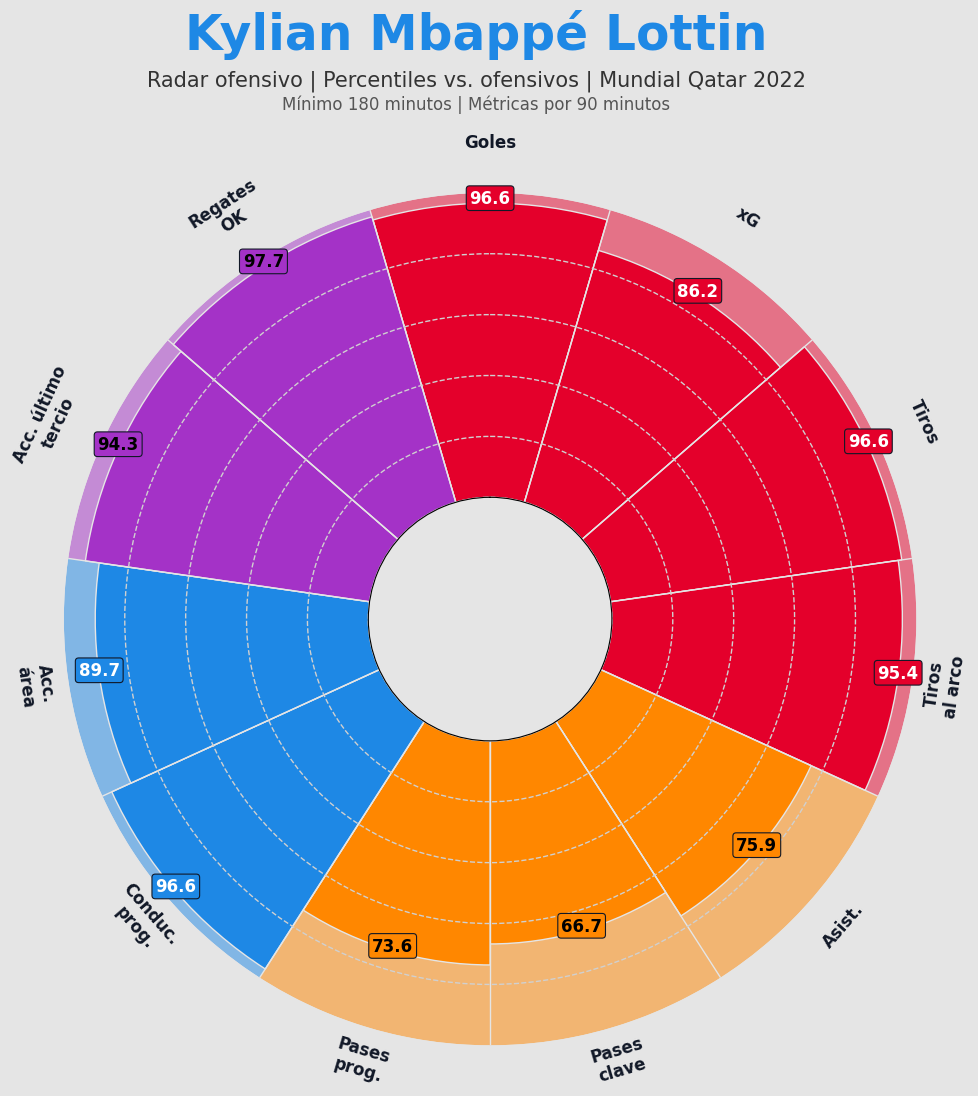

In [349]:
fuente_grafico = "DejaVu Sans"

pizza = PyPizza(
    params=params,
    background_color="#E5E5E5",
    straight_line_color="#E5E5E5",
    straight_line_lw=1,
    last_circle_lw=0,
    other_circle_lw=1,
    other_circle_color="#D0D0D0",
    inner_circle_size=40)

fig, ax = pizza.make_pizza(
    valores,
    figsize=(11, 12),
    color_blank_space="same",
    slice_colors=colores_porcion,
    value_colors=colores_texto,
    value_bck_colors=colores_porcion,
    param_location=115,
    kwargs_slices=dict(
        edgecolor="#E5E5E5",
        linewidth=1),
    kwargs_params=dict(
        color="#111827",
        fontsize=12,
        fontweight="bold",
        fontfamily=fuente_grafico),
    kwargs_values=dict(
        color="#111827",
        fontsize=12,
        fontweight="bold",
        fontfamily=fuente_grafico,
        bbox=dict(
            edgecolor="#111827",
            facecolor="#E5E5E5",
            boxstyle="round,pad=0.2",
            linewidth=0.8)))

fig.set_facecolor("#E5E5E5")

fig.text(
    0.5,
    0.97,
    jugador_objetivo,
    ha="center",
    fontsize=35,
    fontweight="bold",
    fontfamily=fuente_grafico,
    color="#1E88E5")

fig.text(
    0.5,
    0.94,
    f"Radar ofensivo | Percentiles vs. {grupo_posicion} | Mundial Qatar 2022",
    ha="center",
    fontsize=15,
    fontfamily=fuente_grafico,
    color="#333333")

fig.text(
    0.5,
    0.92,
    f"Mínimo {minutos_minimos} minutos | Métricas por 90 minutos",
    ha="center",
    fontsize=12,
    fontfamily=fuente_grafico,
    color="#555555")

plt.show()

In [346]:
columnas_resumen = [
    "player",
    "team",
    "minutos_jugados",
    "posicion_principal"
]

for metrica in metricas_radar:
    columnas_resumen.append(metrica)
    columnas_resumen.append(metrica + "_percentil")

df_jugador[columnas_resumen].T

,374
player,Kylian Mbappé Lottin
team,France
minutos_jugados,653.583333
posicion_principal,Left Wing
goles_p90,0.826214
goles_p90_percentil,96.551724
xg_p90,0.367149
xg_p90_percentil,86.206897
tiros_p90,3.99337
tiros_p90_percentil,96.551724


In [347]:
df_minutos[
    df_minutos["player"].str.contains("Messi", case=False, na=False)
][
    ["player", "team", "minutos_jugados", "posicion_principal", "grupo_posicion"]
]

,player,team,minutos_jugados,posicion_principal,grupo_posicion
0,Lionel Andrés Messi Cuccittini,Argentina,867.6,Right Center Forward,ofensivos


In [348]:
df_posiciones_detalle[
    df_posiciones_detalle["player_name"].str.contains("Messi", case=False, na=False)
][
    ["player_name", "team", "position", "minutos_jugados"]
].sort_values("minutos_jugados", ascending=False)

,player_name,team,position,minutos_jugados
478,Lionel Andrés Messi Cuccittini,Argentina,Right Wing,115.533333
322,Lionel Andrés Messi Cuccittini,Argentina,Right Center Forward,112.833333
1741,Lionel Andrés Messi Cuccittini,Argentina,Right Center Forward,103.833333
656,Lionel Andrés Messi Cuccittini,Argentina,Right Center Forward,96.483333
480,Lionel Andrés Messi Cuccittini,Argentina,Right Wing,95.800000
930,Lionel Andrés Messi Cuccittini,Argentina,Right Center Forward,95.033333
40,Lionel Andrés Messi Cuccittini,Argentina,Right Center Forward,70.400000
566,Lionel Andrés Messi Cuccittini,Argentina,Center Forward,59.433333
324,Lionel Andrés Messi Cuccittini,Argentina,Right Center Forward,54.700000
567,Lionel Andrés Messi Cuccittini,Argentina,Right Wing,36.583333
